In [ ]:
!pip install datasets --quiet

In [ ]:
#importing libraries
import math, random, time
from collections import Counter
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from collections import Counter
import matplotlib.pyplot as plt
from tqdm import tqdm
from datasets import load_dataset
import pandas as pd

#Global constant we're gonna be using everywhere!
SEQ_LEN = 1000     #fixed length of each sequence to be processed(this is given in the assignment)
TOP_K = 10000    #vocabulary size that is to be taken(specified in the assignemnt as well)
SEED = 42      #random seed for reproducibility
BATCH_SIZE = 128   #batch size for training
EPOCHS = 50       #max number of epochs to train the model


#this is the setup for ensuring reproducibility for all random generators
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
#this is created so that we can handle the (x, y, mask) triplets easily while training the model
class CodeDataset(Dataset):
  def __init__(self, sequences):
    self.sequences = sequences

  def __len__(self):
    return len(self.sequences)

  def __getitem__(self, idx):
    return self.sequences[idx]

In [ ]:
# This class is gonna help us perform all the tasks for Task 1
class Loaders:
  def __init__(self, dataset):
    self.dataset = dataset
    self.train = None
    self.val = None
    self.test = None
    self.vocab = None

  #1.) Preprocessing: creating vocabulary from training set only using the top 10,000 most common tokens
      #and adding <PAD> and <UNK> tokens to the vocabulary
  def build_vocab(self):
    c = Counter()
    for j in self.train:
      c.update(j)
    self.vocab = [i for i, _ in c.most_common(TOP_K)]
    self.vocab = ["<PAD>", "<UNK>"] + self.vocab

  #2.)Sequencing: padding/truncating sequences to fixed length of 1000 tokens
     # - we create a mapping from token to id for easy indexing
     # - we tokenize the sequences first, mapping each token to its id and if the token is not in vocab, we map it to <UNK> id
     # - if the length of the tokenized sequence is greater than 1000, we truncate it to 1000 tokens
     # - if the length of the tokenized sequence is less than 1000, we pad it with <PAD> id to make it 1000 tokens
     # - we then create input (x), target (y) and mask (m) tensors for each sequence
     # - x is the tokenized sequence excluding the last token
     # - y is the tokenized sequence excluding the first token
     # - m is a binary mask where 1 indicates that the corresponding token in y is not a <PAD> token and vice veras
     # - the m tensor is used to ignore the loss for <PAD> tokens during training, it is just for convenience
  def create_token_to_id(self):
    return {t:i for i,t in enumerate(self.vocab)}

  def tokenize_to_sequences(self, ds, token_to_id):
    UNK_id = token_to_id.get("<UNK>")
    PAD_id = token_to_id.get("<PAD>")
    sequences = []
    for seq in ds:
      tokens = [token_to_id.get(i, UNK_id) for i in seq]
      if len(tokens) > SEQ_LEN:
        tokens = tokens[:SEQ_LEN]
      else:
        tokens += [PAD_id] * (SEQ_LEN - len(tokens))
      x = torch.tensor(tokens[:-1], dtype = torch.long)
      y = torch.tensor(tokens[1:], dtype = torch.long)
      m = (y != PAD_id).long()
      sequences.append((x,y,m))
    return sequences

  #3.)Create Validation Split: splitting the original training set into 80% training and 20% validation with random state 42
     #as stated in the assignment
  def split(self):
    train_val = self.dataset["train"]
    test = self.dataset["test"]
    idx = list(range(len(train_val)))
    random.shuffle(idx)
    n = int(0.8 * len(train_val))
    train, val = train_val[idx[:n]], train_val[idx[n:]]
    self.train = train["code"]
    self.val = val["code"]
    self.test = test["code"]

  #4.)Build DataLoaders: building efficient DataLoaders for training, validation and testing by applying all the above steps
    # and then wrapping them in CodeDataset as it handles the (x, y, mask) triplets, then creating DataLoader objects with batch size 128
    # and returning them
  def make_loaders(self):
    self.split()
    self.build_vocab()
    token_to_id = self.create_token_to_id()
    train_sequence = self.tokenize_to_sequences(self.train, token_to_id)
    val_sequence = self.tokenize_to_sequences(self.val, token_to_id)
    test_sequence = self.tokenize_to_sequences(self.test, token_to_id)
    train_loader = DataLoader(CodeDataset(train_sequence), batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
    val_loader = DataLoader(CodeDataset(val_sequence), batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
    test_loader = DataLoader(CodeDataset(test_sequence), batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
    return train_loader, val_loader, test_loader, self.vocab, token_to_id


In [ ]:
#we load the CodeXGLUE dataset (Python subset for token-level code completion)
dataset = load_dataset("google/code_x_glue_cc_code_completion_token", "python")

In [ ]:
# instantiating class
loaders = Loaders(dataset)

# generating the dataloaders, vocabulary and token_to_id mapping
train_loader, val_loader, test_loader, vocab, token_to_id = loaders.make_loaders()

With this we complete the Task 1, where at the end we get all the efficient pytorch DataLoaders for train, test, validation splits and also get the vocabulary and token_to_id mapping that is gonna be useful in the future.

# Task 2: Baseline Models - Comparision

### Task 2.1 - Model comparision

In [ ]:
EMBED_DIM = 256   #Dimension for embedding layers for both lstm and rnn architectures (given in the assignment)
NLAYERS = 2  # number of layers for both lstm and rnn architectures (given in the assignment)
HIDDEN_DIM = 512   #dimension for hidden layers in both lstm and rnn architectures (given in the assignment)
DROPOUT = 0.3  #dropout rate for regularization (chosen by us)
MAX_EPOCHS = 50    #max number of epochs to train any model
ACTIVATION_RNN = 'tanh'  #activation function for RNN model (chosen by us)

#### Justification for Chosen Hyperparameters and Strategies

**Embedding Strategy:**  
We use **trainable embeddings from scratch** instead of pre-trained ones like Word2Vec or code2vec. The reason for this is that the vocabulary we are using is quite specific, it contains Python code keywords, identifiers and symbols, which are quite different from natural language text that generic embeddings are trained on. By training embeddings from scratch, the model can learn token representations that are more relevant to thespecific context of Python code, leading to better performance on the code completion task.

**Activation Functions:**  
- **RNN:** Uses the *tanh* activation as it stabilizes gradients. since the same weight matrix gets used in each time step, even small increae in actiavtions can grow exponentially, which is why we use tanh as it bounds the outputs to [-1,1]. We dont use relu here as it is unbounded in the positive direction, hence causing the exploding gradient problem.  
- **LSTM:** Fixed in LSTM(tanh+sigmoid), so we cant chose it


**Dropout Rate (0.3):**  
We chose the value of 0.3 as it gives us a nice tradeoff between underfitting and overfitting, as low values could lead to low regularization, allowing the model to overfit, and high values could lead to excessive regularization(which happens due to high deactivation of neurons) which could lead to underfitting

**Max Epochs (50):**  
A higher upper limit ensures enough time for convergence. With early stopping implemented, the training halts automatically once validation loss stagnates, making 50 a safe ceiling.


In [ ]:
# Our RNN model class

class RNNModel(nn.Module):
    def __init__(self, vocab_size, embed_dim = EMBED_DIM, hidden_dim = HIDDEN_DIM, num_layers = NLAYERS, dropout=DROPOUT, \
                 nonlinearity=ACTIVATION_RNN):
        super().__init__()

        # REQUIREMENT: Embedding Layer
        # This layer creates trainable embeddings from scratch. padding_idx is set to the pad token with out token_to_id mapping
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx = token_to_id.get("<PAD>"))

        # REQUIREMENT: Recurrent Stack
        # this is the core RNN layer
        # - the cell type is `nn.RNN` as required for this model
        # - `embed_dim` sets the expected size of the input vectors (coming from the embedding layer) (256)
        # - `num_layers` sets the number of recurrent layers to stack (2)
        # - `hidden_dim` sets the number of hidden units per layer (512)
        # - `nonlinearity` specifies the activation function (tanh)
        # - the `dropout` parameter here applies dropout *between* the recurrent layers, fulfilling one part of the regularization
        # requirement
        self.core = nn.RNN(embed_dim, hidden_dim, num_layers, nonlinearity=nonlinearity, dropout=dropout, batch_first=True)

        # REQUIREMENT: Output Layer
        # this is the fully connected (Linear) layer for the output.
        # - it maps the hidden state representation to a vector of logits.
        # - the output size of this layer is `vocab_size`, which matches the vocabulary size
        #   as required.
        self.fc = nn.Linear(hidden_dim, vocab_size)

        # REQUIREMENT: Regularization
        # this defines the dropout layer that will be applied before the output layer.
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, h=None):
        x = self.embedding(x)
        x = self.dropout(x)
        x, h = self.core(x, h)

        # REQUIREMENT: Regularization
        # here, we apply the dropout layer to the output of the recurrent stack before it is passed to the final output layer
        x = self.dropout(x)

        x = self.fc(x)
        return x, h

    def init_hidden(self):
        return torch.zeros(NLAYERS, BATCH_SIZE, HIDDEN_DIM).to(device)


In [ ]:
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim = EMBED_DIM, hidden_dim = HIDDEN_DIM, num_layers = NLAYERS, dropout=DROPOUT):
        super().__init__()

        # REQUIREMENT: Embedding Layer
        # This layer creates trainable embeddings from scratch. padding_idx is set to the pad token with out token_to_id mapping
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx = token_to_id.get("<PAD>"))

        # REQUIREMENT: Recurrent Stack
        # This is the core LSTM layer.
        # - The cell type is `nn.LSTM` as required for this model.
        # - `embed_dim` sets the expected size of the input vectors (coming from the embedding layer) (256)
        # - `num_layers` sets the number of recurrent layers to stack (2)
        # - `hidden_dim` sets the number of hidden units per layer (512)
        # - the `dropout` parameter here applies dropout *between* the recurrent layers, fulfilling one part of the regularization
        # requirement
        self.core = nn.LSTM(embed_dim, hidden_dim, num_layers, dropout=dropout, batch_first=True)

        # REQUIREMENT: Output Layer
        # this is the fully connected (Linear) layer for the output.
        # - it maps the hidden state representation to a vector of logits.
        # - the output size of this layer is `vocab_size`, which matches the vocabulary size
        #   as required.
        self.fc = nn.Linear(hidden_dim, vocab_size)

        # REQUIREMENT: Regularization
        # This defines the dropout layer that will be applied before the output layer.
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, h=None):
        x = self.embedding(x)
        x = self.dropout(x)
        x, h = self.core(x, h)

        # REQUIREMENT: Regularization
        # here, we apply the dropout layer to the output of the recurrent stack before it is passed to the final output layer
        x = self.dropout(x)

        x = self.fc(x)
        return x, h

    def init_hidden(self):
        # For an LSTM, the hidden state is a tuple containing both the hidden state and the cell state. Both need to be initialized.
        return (torch.zeros(NLAYERS, BATCH_SIZE, HIDDEN_DIM).to(device),
                torch.zeros(NLAYERS, BATCH_SIZE, HIDDEN_DIM).to(device))

### Task 2.2 - Training and Validation

In [ ]:
# REQUIREMENT: Loss Function
# This function calculates the cross-entropy loss. It uses nn.functional.cross_entropy as specified and it uses the
# ignore_index=pad_idx parameter, which ensures that the loss is NOT computed on the padding tokens
def cross_entropy_with_mask(pred_logits, target, pad_idx):
    vocab_size = pred_logits.size(-1)
    return nn.functional.cross_entropy(pred_logits.view(-1, vocab_size),
                                       target.view(-1),
                                       ignore_index=pad_idx)

# .view() gets our pred_logits and target to be of the required size
# pred_logits = (batch_size, sequence_len, vocab_size) --> (batch_size * sequence_len, vocab_size)
# target = (batch_size, sequence_length) --> (batch_size * sequence_length)

In [ ]:
# REQUIREMENT: What to Measure on the Validation Set (Top-5 Accuracy)
# This function calculates Top-5 accuracy hits for a batch, ignoring padding
# it also checks if the true token is within the model's top 5 predictions.

def calculate_batch_hit_and_tokens(pred_logits, target, mask):
    # as we are just calculating just metrics, we dont need to calculate gradients
    with torch.no_grad():
        # converting 'm' tensor to boolean mask(as it is convenient later on)
        bool_mask = mask.bool()
        # get the number of non pad tokens
        total_non_pad_tokens = bool_mask.sum().item()
        #get the indices of the top 5 most likely tokens for each position.
        topk = pred_logits.topk(5, dim=-1).indices
        #check if the target token is within the top 5 predictions for any non-padded position.
        hits = (topk == target.unsqueeze(-1)).any(dim=-1) & bool_mask
        #sum up the total number of times this occurs
        total_hits = hits.sum().item()
        return total_hits, total_non_pad_tokens

In [ ]:
def top5_accuracy(total_hits, total_non_pad_tokens):
    if total_non_pad_tokens == 0:
        return 0.0
    return 100 * total_hits / total_non_pad_tokens

In [ ]:
# REQUIREMENT: What to Measure on the Validation Set (Perplexity - PPL)
def perplexity(avg_loss):
    return math.exp(avg_loss)

In [ ]:
# This function encapsulates the training logic for a single epoch.

def train_one_epoch(model, loader, opt):
    # Set the model to training mode (enables dropout, etc.).
    model.train()
    total_loss, total_top5, total_tokens = 0.0, 0, 0
    pad_idx = token_to_id["<PAD>"]

    # Iterate over batches from the data loader.
    for x, y, m in tqdm(loader, desc="Training"):
        x, y, m = x.to(device), y.to(device), m.to(device)
        # Clear previous gradients.
        opt.zero_grad(set_to_none=True)
        # Forward pass: get model predictions.
        pred_logits, _ = model(x)
        # Calculate the loss, ignoring padding.
        loss = cross_entropy_with_mask(pred_logits, y, pad_idx)
        # Backward pass: compute gradients.
        loss.backward()
        # Clip gradients to prevent them from exploding.
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        # Update model weights.
        opt.step()
        # Calculate metrics for this batch.
        hits, non_pad_tokens = calculate_batch_hit_and_tokens(pred_logits, y, m)
        # Accumulate total loss and metrics across all batches.
        total_loss += loss.item() * non_pad_tokens
        total_top5 += hits
        total_tokens += non_pad_tokens

    # Calculate average loss, accuracy, and perplexity for the entire epoch.
    avg_loss = total_loss / total_tokens
    acc = top5_accuracy(total_top5, total_tokens)
    ppl = perplexity(avg_loss)
    return avg_loss, acc, ppl

In [ ]:
# REQUIREMENT: Validation
# This function evaluates the model on a dataset (e.g., the validation set).
# It calculates all the required metrics after an epoch.

def evaluate(model, loader):
    # Set the model to evaluation mode (disables dropout, etc.).
    model.eval()
    total_loss, total_top5, total_tokens = 0.0, 0, 0
    pad_idx = token_to_id["<PAD>"]

    # Disable gradient computation for the evaluation phase.
    with torch.no_grad():
        # Iterate over batches from the data loader.
        for x, y, m in tqdm(loader, desc="Evaluating"):
            x, y, m = x.to(device), y.to(device), m.to(device)
            # Forward pass to get predictions.
            pred_logits, _ = model(x)
            # Calculate loss and metrics for the batch.
            loss = cross_entropy_with_mask(pred_logits, y, pad_idx)
            hits, non_pad_tokens = calculate_batch_hit_and_tokens(pred_logits, y, m)
            # Accumulate total loss and metrics.
            total_loss += loss.item() * non_pad_tokens
            total_top5 += hits
            total_tokens += non_pad_tokens

    # Calculate average metrics for the entire evaluation dataset.
    avg_loss = total_loss / total_tokens
    acc = top5_accuracy(total_top5, total_tokens)
    ppl = perplexity(avg_loss)
    return avg_loss, acc, ppl

In [ ]:
# This function orchestrates the entire training and validation process.
def train(model, arch, train_loader, val_loader, n_epochs=MAX_EPOCHS, lr=1e-3, patience=3, min_delta=0.002):
    # REQUIREMENT: Optimizer
    # The Adam optimizer is used, as specified in the assignment.
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    # Initialize variables for early stopping and tracking best model.
    best_val_loss = float('inf')
    epochs_no_improve = 0

    # Lists to store the history of metrics for plotting.
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    train_ppls, val_ppls = [], []

    total_time_start = time.time()
    # Main training loop over the specified number of epochs.
    for epoch in range(1, n_epochs + 1):
        start_time = time.time()
        # Perform one epoch of training and one epoch of validation.
        train_loss, train_acc, train_ppl = train_one_epoch(model, train_loader, opt)
        val_loss, val_acc, val_ppl = evaluate(model, val_loader)

        # Append the metrics for this epoch to the history lists.
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        train_ppls.append(train_ppl)
        val_ppls.append(val_ppl)

        elapsed = time.time() - start_time
        print(f"Epoch {epoch}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}, "
              f"Val Acc={val_acc:.2f}%, "
              f"Val PPL={val_ppl:.2f}, Time={elapsed:.2f}s")

        # REQUIREMENT: Training Duration (Early Stopping)
        # This logic implements early stopping based on validation loss, which is one
        # of the suggested strategies to determine training duration.
        if best_val_loss - val_loss > min_delta:
            improvement = best_val_loss - val_loss
            # Save the model if validation loss has improved.
            best_val_loss = val_loss
            torch.save(model, f"best_model_{arch}.pt")
            print(f"Best model saved (Val Loss improved by {improvement:.4f}).")
            epochs_no_improve = 0
        else:
            # Increment the counter if no improvement.
            epochs_no_improve += 1
            print(f"No Val Loss improvement >= {min_delta:.4f} for {epochs_no_improve} epoch(s).")

        # If no improvement for 'patience' number of epochs, stop training.
        if epochs_no_improve >= patience:
            print(f"Early stopping triggered after {patience} epochs with insufficient Val Loss improvement.")
            break

    # calculating the total time for training
    total_time = time.time() - total_time_start
    return (train_losses, val_losses), (train_accs, val_accs), (train_ppls, val_ppls), total_time



In [ ]:
# REQUIREMENT: Plot the validation Top-5 Accuracy
# This function plots the history of loss, Top-5 accuracy, and perplexity.

def plot_history(history, arch):
    """Plots training and validation history for a given model architecture."""
    (train_losses, val_losses), (val_accs), (val_ppls) = history
    epochs = range(1, len(train_losses) + 1)

    fig, axes = plt.subplots(3, 1, figsize=(10, 15), sharex=True)
    fig.suptitle(f'{arch.upper()} Model Training History', fontsize=16)

    # ---- Loss ----
    axes[0].plot(epochs, train_losses, 'b-o', label='Training Loss')
    axes[0].plot(epochs, val_losses, 'r-o', label='Validation Loss')
    axes[0].set_title('Training vs Validation Loss', fontsize=13)
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)

    # ---- Top-5 Accuracy ----
    axes[1].plot(epochs, val_accs, 'r-o', label='Validation Top-5 Accuracy')
    axes[1].set_title('Validation Top-5 Accuracy', fontsize=13)
    axes[1].set_ylabel('Top-5 Accuracy (%)')
    axes[1].legend()
    axes[1].grid(True)

    # ---- Perplexity ----
    axes[2].plot(epochs, val_ppls, 'r-o', label='Validation Perplexity')
    axes[2].set_title('Validation Perplexity', fontsize=13)
    axes[2].set_ylabel('Perplexity')
    axes[2].set_xlabel('Epochs')
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


#### Training our RNN model

In [ ]:
#instantiating the RNN model
rnn_model = RNNModel(len(vocab)).to(device)

In [ ]:
#training
(rnn_train_losses, rnn_val_losses), (rnn_train_accs, rnn_val_accs), (rnn_train_ppls, rnn_val_ppls), rnn_total_time \
    = train(rnn_model, "rnn", train_loader, val_loader, n_epochs=EPOCHS, lr=1e-3)

Evaluating: 100%|██████████| 157/157 [00:13<00:00, 11.95it/s]


Epoch 1: Train Loss=2.6191, Val Loss=2.1636, Val Acc=79.68%, Val PPL=8.70, Time=113.37s
Best model saved (Val Loss improved by inf).


Evaluating: 100%|██████████| 157/157 [00:13<00:00, 11.93it/s]


Epoch 2: Train Loss=2.1875, Val Loss=2.0112, Val Acc=81.23%, Val PPL=7.47, Time=113.44s
Best model saved (Val Loss improved by 0.1523).


Evaluating: 100%|██████████| 157/157 [00:13<00:00, 11.91it/s]


...

Epoch 12: Train Loss=1.9117, Val Loss=1.8164, Val Acc=83.27%, Val PPL=6.15, Time=113.42s
No Val Loss improvement >= 0.0020 for 1 epoch(s).


Evaluating: 100%|██████████| 157/157 [00:13<00:00, 11.88it/s]


Epoch 13: Train Loss=1.9145, Val Loss=1.8062, Val Acc=83.38%, Val PPL=6.09, Time=113.48s
No Val Loss improvement >= 0.0020 for 2 epoch(s).


Evaluating: 100%|██████████| 157/157 [00:13<00:00, 11.92it/s]

Epoch 14: Train Loss=1.9212, Val Loss=1.8087, Val Acc=83.39%, Val PPL=6.10, Time=113.61s
No Val Loss improvement >= 0.0020 for 3 epoch(s).
Early stopping triggered after 3 epochs with insufficient Val Loss improvement.


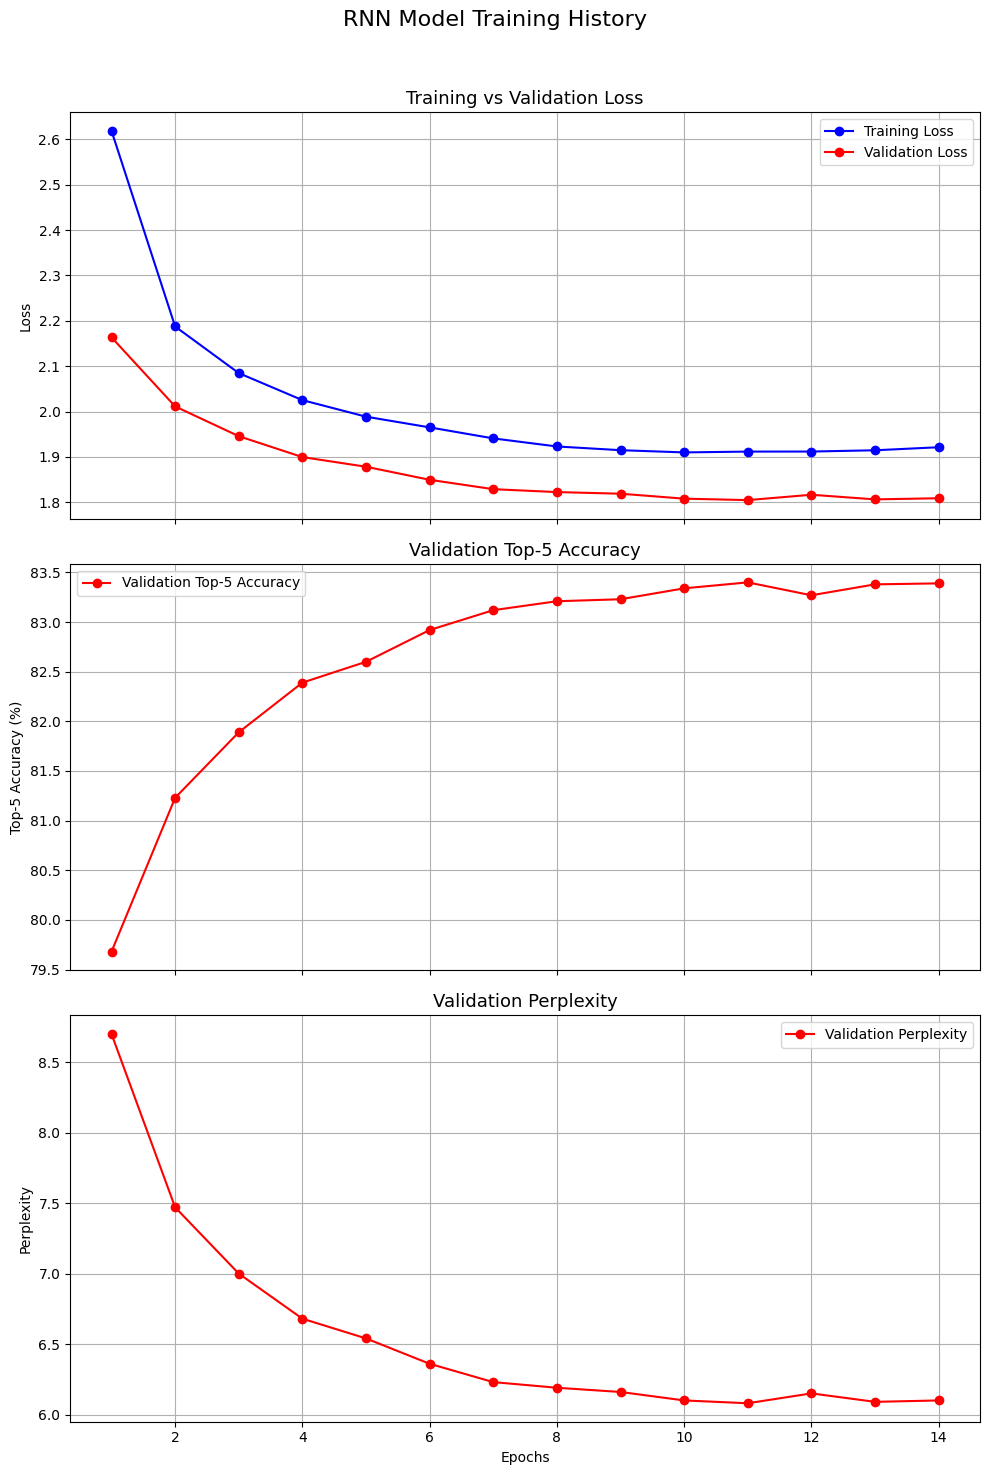

In [ ]:
#plotting
rnn_history = ((rnn_train_losses, rnn_val_losses), (rnn_val_accs), (rnn_val_ppls))
plot_history(rnn_history, "RNN")

In [ ]:
print("Time taken to train RNN model: {:.2f} seconds".format(rnn_total_time))

Time taken to train RNN model: 1593.36 seconds


#### Training our LSTM Model

In [ ]:
#instantiating the LSTM model
lstm_model = LSTMModel(len(vocab)).to(device)

In [ ]:
#training
(lstm_train_losses, lstm_val_losses), (lstm_train_accs, lstm_val_accs), (lstm_train_ppls, lstm_val_ppls), lstm_total_time \
    = train(lstm_model, "lstm", train_loader, val_loader, n_epochs=EPOCHS, lr=1e-3)

Evaluating: 100%|██████████| 157/157 [00:11<00:00, 13.40it/s]


Epoch 1: Train Loss=3.2518, Val Loss=2.4080, Val Acc=76.99%, Val PPL=11.11, Time=121.99s
Best model saved (Val Loss improved by inf).


Evaluating: 100%|██████████| 157/157 [00:11<00:00, 13.42it/s]


Epoch 2: Train Loss=2.3122, Val Loss=2.0725, Val Acc=80.43%, Val PPL=7.94, Time=126.18s
Best model saved (Val Loss improved by 0.3356).


Evaluating: 100%|██████████| 157/157 [00:11<00:00, 13.40it/s]


...

Epoch 48: Train Loss=1.2337, Val Loss=1.2291, Val Acc=89.94%, Val PPL=3.42, Time=126.46s
Best model saved (Val Loss improved by 0.0027).


Evaluating: 100%|██████████| 157/157 [00:11<00:00, 13.42it/s]


Epoch 49: Train Loss=1.2311, Val Loss=1.2290, Val Acc=89.95%, Val PPL=3.42, Time=126.33s
No Val Loss improvement >= 0.0020 for 1 epoch(s).


Evaluating: 100%|██████████| 157/157 [00:11<00:00, 13.38it/s]


Epoch 50: Train Loss=1.2283, Val Loss=1.2244, Val Acc=90.01%, Val PPL=3.40, Time=126.32s
Best model saved (Val Loss improved by 0.0047).


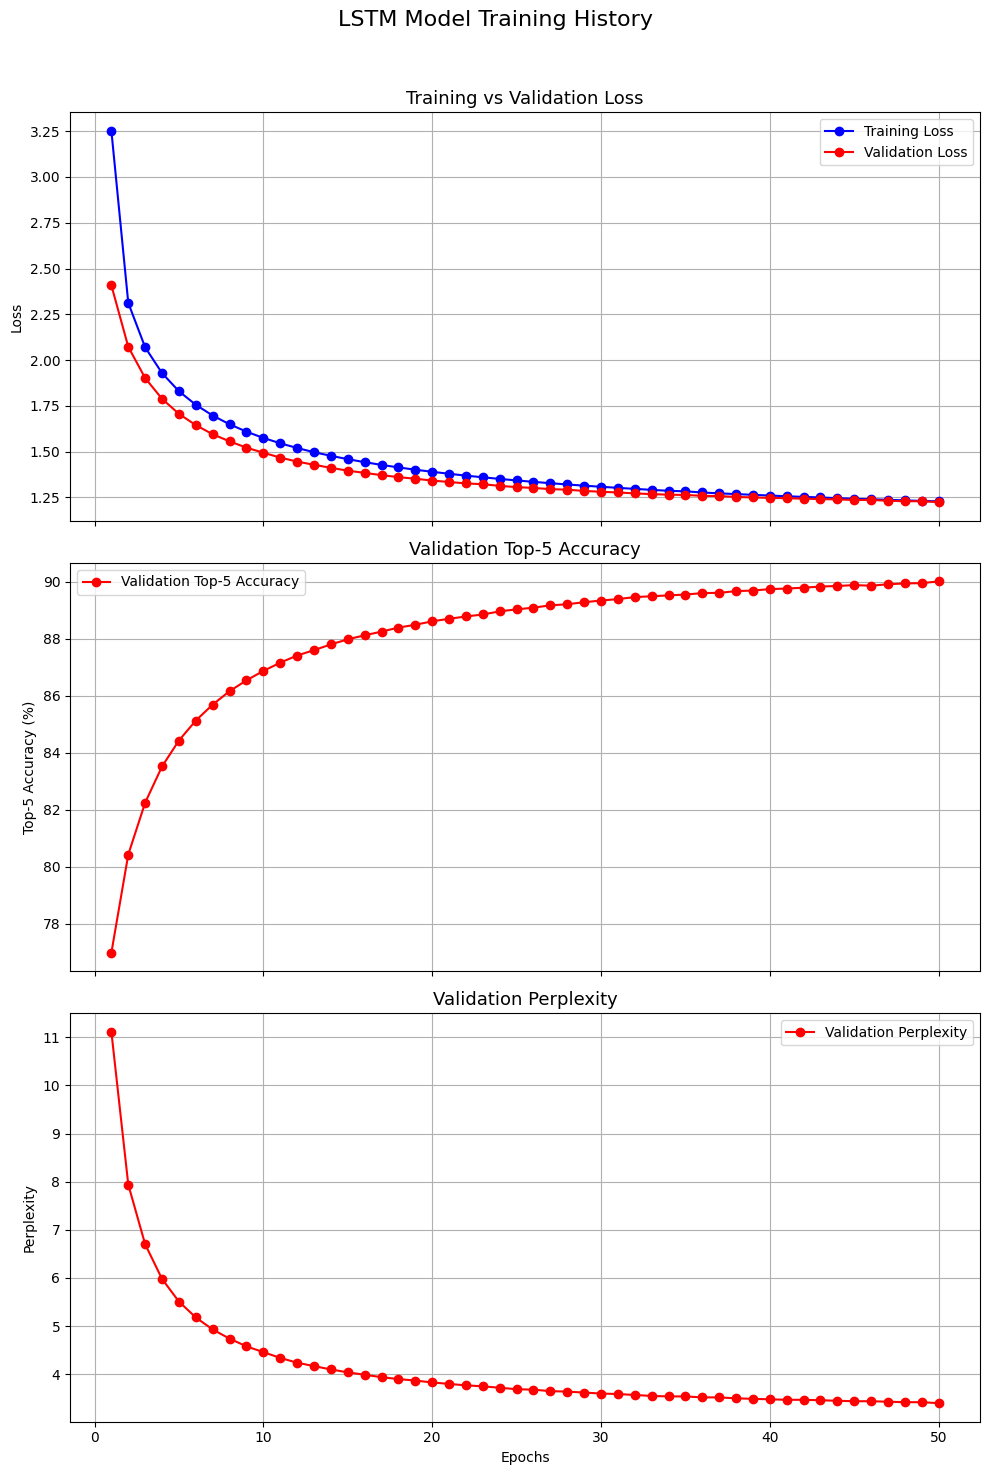

In [ ]:
#plotting
lstm_history = ((lstm_train_losses, lstm_val_losses), (lstm_val_accs), (lstm_val_ppls))
plot_history(lstm_history, "LSTM")

In [ ]:
print("Time taken to train LSTM model: {:.2f} seconds".format(lstm_total_time))

Time taken to train LSTM model: 6318.44 seconds


### Task 2.3 - Final Evaluation and Reporting

In [ ]:
# REQUIREMENT: Report Your Results (Total Number of Trainable Parameters)
def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [ ]:
# REQUIREMENT: Final Evaluation & Reporting
# This function orchestrates the final test phase as per the instructions.

def test(model_path, test_loader, arch):
    """
    Loads the best saved model, evaluates it, and counts its parameters.
    """
    # Step 1 & 2: Choose and load the best model checkpoint, then run the final test.
    model = torch.load(model_path, map_location=device)
    model.to(device)
    print(f"Successfully loaded best model from '{model_path}'.")

    # Step 4: Report the total number of trainable parameters.
    num_params = count_trainable_parameters(model)
    print(f"The '{arch}' model has {num_params:,} trainable parameters.")

    # Step 3: Calculate the final metrics (Top-5 Accuracy and PPL) on the test set.
    start_time = time.time()
    test_loss, test_acc, test_ppl = evaluate(model, test_loader)
    elapsed = time.time() - start_time

    # Print the final performance for clarity.
    print("\n--- Test Results ---")
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc:.2f}%")
    print(f"Test Perplexity: {test_ppl:.2f}")
    print(f"Inference Time: {elapsed:.2f}s")
    print("--------------------")

    return num_params, test_loss, test_acc, test_ppl, elapsed

In [ ]:
#evaluating on the test set with the RNN model
rnn_params, rnn_test_loss, rnn_test_acc, rnn_test_ppl, rnn_inference_time = test(f"best_model_rnn.pt", test_loader, "RNN")

Successfully loaded best model from 'best_model_rnn.pt'.
The 'RNN' model has 8,611,090 trainable parameters.


Evaluating: 100%|██████████| 391/391 [00:32<00:00, 11.86it/s]


--- Test Results ---
Test Loss: 1.8001
Test Accuracy: 83.42%
Test Perplexity: 6.05
Inference Time: 32.96s
--------------------


In [ ]:
#evealuating on the test set with the LSTM model
lstm_params, lstm_test_loss, lstm_test_acc, lstm_test_ppl, lstm_inference_time = test(f"best_model_lstm.pt", test_loader, "LSTM")

Successfully loaded best model from 'best_model_lstm.pt'.
The 'LSTM' model has 11,369,746 trainable parameters.


Evaluating: 100%|██████████| 391/391 [00:34<00:00, 11.29it/s]


--- Test Results ---
Test Loss: 1.2180
Test Accuracy: 90.07%
Test Perplexity: 3.38
Inference Time: 34.63s
--------------------


In [3]:
# REQUIREMENT: Report Your Results (Present findings in a clear table)
# This section constructs a pandas DataFrame to display the final comparison between the RNN and LSTM models

results_data = {
    "Metric": [
        "Trainable Parameters",
        "Test Loss",
        "Test Top-5 Accuracy (%)",
        "Test Perplexity",
        "Inference Time (s)"
    ],
    "RNN": [
        f"{rnn_params:,}",
        f"{rnn_test_loss:.4f}",
        f"{rnn_test_acc:.2f}",
        f"{rnn_test_ppl:.4f}",
        f"{rnn_inference_time:.2f}"
    ],
    "LSTM": [
        f"{lstm_params:,}",
        f"{lstm_test_loss:.4f}",
        f"{lstm_test_acc:.2f}",
        f"{lstm_test_ppl:.4f}",
        f"{lstm_inference_time:.2f}"
    ]
}

df_results = pd.DataFrame(results_data)

styled = (
    df_results.style
    .set_caption("🔹 Final Test Results Comparison (RNN vs LSTM)")
    .set_table_styles(
        [
            {"selector": "caption", "props": [("font-size", "16px"), ("font-weight", "bold"), ("text-align", "center")]},
            {"selector": "th", "props": [("background-color", "#2E86C1"), ("color", "white"), ("text-align", "center")]},
            {"selector": "td", "props": [("text-align", "center"), ("border", "1px solid #999")]}
        ]
    )
)

styled


,Metric,RNN,LSTM
0,Trainable Parameters,"8,611,090","11,369,746"
1,Test Loss,1.8001,1.2180
2,Test Top-5 Accuracy (%),83.42,90.07
3,Test Perplexity,6.0505,3.3804
4,Inference Time (s),32.96,34.63


# Task 3 - Residual Recurrent Model

### Task 3.1 - Implementation
The best performing model from task 2 is the LSTM model, hence we will chose it as the base architecture for our Residual Recurrent Model

In [ ]:
# This class defines the new model with a residual connection.
class ResidualRecurrentModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=EMBED_DIM, hidden_dim=HIDDEN_DIM, dropout=DROPOUT):
        super().__init__()
        self.hidden_dim = hidden_dim

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.dropout = nn.Dropout(dropout)

        # Base Architecture: Two LSTM layers are used, enhancing the best model from Task 2.
        self.core1 = nn.LSTM(embed_dim,  hidden_dim, num_layers=1, batch_first=True)
        self.core2 = nn.LSTM(hidden_dim, hidden_dim, num_layers=1, batch_first=True)

        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, h=None):
        if h is None:
            h1c1 = h2c2 = None
        else:
            h1c1, h2c2 = h

        # Pass input through the embedding layer and dropout.
        x = self.dropout(self.embedding(x))
        # Pass the sequence through the first recurrent layer.
        y1, h1c1 = self.core1(x, h1c1)
        # Pass the output of the first layer to the second recurrent layer.
        y2, h2c2 = self.core2(self.dropout(y1), h2c2)

        # REQUIREMENT: Residual Connection
        # The final output is the element-wise sum of the first layer's output (y1)
        # and the second layer's output (y2), creating the residual (skip) connection.
        y = self.dropout(y1 + y2)

        # The final linear layer for vocabulary prediction takes the combined output as input.
        y = self.fc(y)
        return y, (h1c1, h2c2)

    def init_hidden(self):
        H = self.hidden_dim
        h1 = torch.zeros(1, BATCH_SIZE, H, device=device)
        c1 = torch.zeros(1, BATCH_SIZE, H, device=device)
        h2 = torch.zeros(1, BATCH_SIZE, H, device=device)
        c2 = torch.zeros(1, BATCH_SIZE, H, device=device)
        return ((h1, c1), (h2, c2))

### Task 3.2 - Training

In [ ]:
#instantiating the model
residual_model = ResidualRecurrentModel(len(vocab)).to(device)

In [ ]:
# The new residual model is trained using the exact same train function and protocol (optimizer, loss function, epochs, early
# stopping) as in the previous task.
(residual_train_losses, residual_val_losses), (residual_train_accs, residual_val_accs), (residual_train_ppls, residual_val_ppls), residual_total_time \
    = train(residual_model, "residual_lstm", train_loader, val_loader, n_epochs=EPOCHS, lr=1e-3)

Evaluating: 100%|██████████| 157/157 [00:13<00:00, 11.48it/s]


Epoch 1: Train Loss=2.5002, Val Loss=1.9734, Val Acc=81.70%, Val PPL=7.20, Time=130.60s
Best model saved (Val Loss improved by inf).


Evaluating: 100%|██████████| 157/157 [00:13<00:00, 11.46it/s]


Epoch 2: Train Loss=1.9335, Val Loss=1.7448, Val Acc=84.24%, Val PPL=5.72, Time=131.57s
Best model saved (Val Loss improved by 0.2286).


Evaluating: 100%|██████████| 157/157 [00:13<00:00, 11.46it/s]


...

Epoch 48: Train Loss=1.1663, Val Loss=1.1960, Val Acc=90.48%, Val PPL=3.31, Time=131.50s
Best model saved (Val Loss improved by 0.0035).


Evaluating: 100%|██████████| 157/157 [00:13<00:00, 11.45it/s]


Epoch 49: Train Loss=1.1649, Val Loss=1.1945, Val Acc=90.50%, Val PPL=3.30, Time=131.27s
No Val Loss improvement >= 0.0020 for 1 epoch(s).


Evaluating: 100%|██████████| 157/157 [00:13<00:00, 11.45it/s]

Epoch 50: Train Loss=1.1626, Val Loss=1.1947, Val Acc=90.51%, Val PPL=3.30, Time=131.65s
No Val Loss improvement >= 0.0020 for 2 epoch(s).


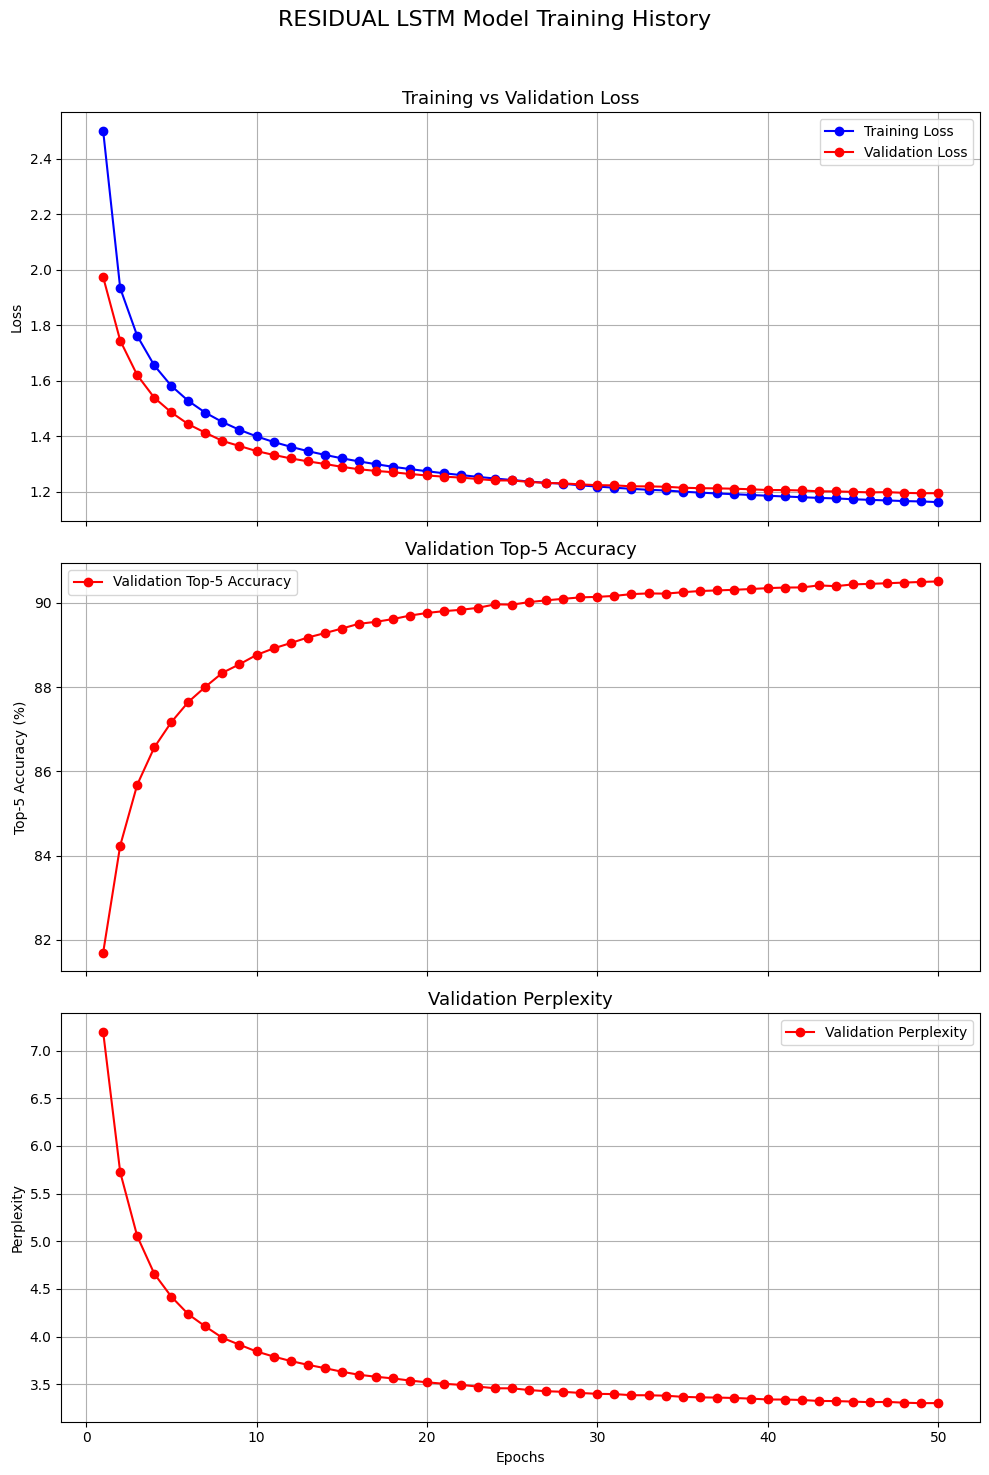

In [ ]:
#plotting
residual_history = ((residual_train_losses, residual_val_losses), (residual_val_accs), (residual_val_ppls))
plot_history(residual_history, "Residual LSTM")

In [ ]:
print("Time taken to train Residual LSTM model: {:.2f} seconds".format(residual_total_time))

Time taken to train Residual LSTM model: 6580.61 seconds


### Task 3.3 - Evaluation and Reporting

In [ ]:
#Evaluating our residual model on the test set
residual_params, residual_test_loss, residual_test_acc, residual_test_ppl, residual_inference_time = test(f"best_model_residual_lstm.pt", test_loader, "Residual LSTM")

Successfully loaded best model from 'best_model_residual_lstm.pt'.
The 'Residual LSTM' model has 11,369,746 trainable parameters.


Evaluating: 100%|██████████| 391/391 [00:34<00:00, 11.46it/s]


--- Test Results ---
Test Loss: 1.1896
Test Accuracy: 90.54%
Test Perplexity: 3.29
Inference Time: 34.11s
--------------------


In [1]:
# This section constructs a DataFrame to compare the final test metrics of the
# new residual model directly against the best-performing baseline from Task 2 (the LSTM model).

results_data = {
    "Metric": [
        "Trainable Parameters",
        "Test Loss",
        "Test Top-5 Accuracy (%)",
        "Test Perplexity",
        "Inference Time (s)"
    ],
    "LSTM": [
        f"{lstm_params:,}",
        f"{lstm_test_loss:.4f}",
        f"{lstm_test_acc:.2f}",
        f"{lstm_test_ppl:.4f}",
        f"{lstm_inference_time:.2f}"
    ],
    "Residual LSTM": [
        f"{residual_params:,}",
        f"{residual_test_loss:.4f}",
        f"{residual_test_acc:.2f}",
        f"{residual_test_ppl:.4f}",
        f"{residual_inference_time:.2f}"
    ]
}

df_results = pd.DataFrame(results_data)

styled = (
    df_results.style
    .set_caption("🔹 Final Test Results Comparison — LSTM vs Residual LSTM")
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-size", "16px"), ("font-weight", "bold"), ("text-align", "center")]},
        {"selector": "th",
         "props": [("background-color", "#2874A6"), ("color", "white"), ("text-align", "center")]},
        {"selector": "td",
         "props": [("text-align", "center"), ("border", "1px solid #aaa")]}
    ])
)

styled


,Metric,LSTM,Residual LSTM
0,Trainable Parameters,"11,369,746","11,369,746"
1,Test Loss,1.2180,1.1896
2,Test Top-5 Accuracy (%),90.07,90.54
3,Test Perplexity,3.3804,3.2859
4,Inference Time (s),34.63,34.11


Since the best top-5 accuracy we are getting is with the Residual LSTM model, we save it as our final model to be submitted.

In [ ]:
original_model_path = 'best_model_residual_lstm.pt'  # Our residual lstm model
new_model_path = 'best_model_25AI60R12.pt'      # The name format described in the assignment
                                                # we would save it to

print(f"Loading model from: {original_model_path}")
model_to_rename = torch.load(original_model_path, map_location=device, weights_only=False)
print("Model loaded successfully.")

print(f"Saving model to: {new_model_path}")
torch.save(model_to_rename, new_model_path)
print("Model saved with a new name successfully.")

Loading model from: best_model_residual_lstm.pt
Model loaded successfully.
Saving model to: best_model_25AI60R12.pt
Model saved with a new name successfully.
